In [2]:
import warnings
from typing import Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import validation_curve, learning_curve

In [4]:
data = pd.read_csv('data.csv')
print('data.shape = {} rows, {} cols'.format(*data.shape))
data.head(2)

data.shape = 100000 rows, 394 cols


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
selected_features = ['TransactionAmt', 'isFraud', 'card1','C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1']
data = data[selected_features]

In [9]:
x_train, x_valid = train_test_split(
    data.drop(['isFraud'],axis=1), train_size=0.7, shuffle=True, random_state=1
)
y_train, y_valid = train_test_split(
    data['isFraud'], train_size = 0.7, shuffle=True, random_state=1
)

print('x_train.shape = {} rows, {} cols'.format(*x_train.shape))
print('x_valid.shape = {} rows, {} cols'.format(*x_valid.shape))

x_train.shape = 70000 rows, 17 cols
x_valid.shape = 30000 rows, 17 cols


In [14]:
model = DecisionTreeClassifier(random_state=1)
model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=1)

In [16]:
# оценим значение метрики качества на train и на valid

train_score = roc_auc_score(y_train, model.predict_proba(x_train)[:, 1])
valid_score = roc_auc_score(y_valid, model.predict_proba(x_valid)[:, 1])

print(f'Train_score: {round(train_score, 3)}, Valid_score: {round(valid_score, 4)}')

Train_score: 1.0, Valid_score: 0.7844


In [18]:
importance = pd.DataFrame({
    'features': x_train.columns,
    'importance': model.feature_importances_
})

importance = importance.sort_values(by='importance', ascending=False)
importance = importance.reset_index(drop=True)
importance.head(2) # эти параметры больше всего влияют на предсказания модели

,features,importance
0,card1,0.236822
1,TransactionAmt,0.156300


**Разделяющая гиперплоскость решающего дерева** 

Для визуализации разделяющей гиперплоскости выберем 2 наиболее важных признака. Это нужно для удобной визуализации данных на плоскости.

In [19]:
def get_grid(data):
    x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
    y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
    return np.meshgrid(
        np.arange(x_min, x_max, 0.01),
        np.arange(y_min, y_max, 0.01)
    ) # каждая точка сетки будет использоваться для предсказания, чтобы показать как модель разделяет пространство

In [20]:
model = DecisionTreeClassifier(random_state=27)
model.fit(
    X = x_train[['card1', 'TransactionAmt']].sample(5000),
    y = y_train.sample(5000)
)


DecisionTreeClassifier(random_state=27)

**Настройка гиперпараметров дерева**
Визуализация процесса настройки гиперпараметра алгоритма машинного обучения. Визуализируются значение метрики качества на обучающей и на тестовой части данных, на валидационной части данных и доверительные интервалы. 

In [32]:
def plot_validation_curves(train_scores: np.array,
                          valid_scores: np.array,
                          figsize: Tuple[int, int] = (8, 8)):

    fig = plt.figure(figsize=figsize)

    plt.title('Validation Curves', size=15)
    plt.plot(
        range(train_scores.shape[0]),
        np.mean(train_scores, axis=1),
        label='train',
        linewidth=3,
        marker='s'
    )
    plt.fill_between(
        x=range(train_scores.shape[0]),
        y1=np.mean(train_scores, axis=1)-np.std(train_scores, axis=1),
        y2=np.mean(train_scores, axis=1)+np.std(train_scores, axis=1),
        alpha=0.25
    )


    plt.plot(
        range(train_scores.shape[0]),
        np.mean(valid_scores, axis=1),
        label='valid',
        linewidth=3,
        marker='s'
    )
    plt.fill_between(
        x=range(train_scores.shape[0]),
        y1=np.mean(valid_scores, axis=1)-np.std(valid_scores, axis=1),
        y2=np.mean(valid_scores, axis=1)+np.std(valid_scores, axis=1),
        alpha=0.25
    )

    plt.legend(loc='best', fontsize=14)
    plt.ylabel('roc_auc', size=15)

In [33]:
train_scores, valid_scores = validation_curve(
    X=x_train,
    y=y_train,
    estimator=DecisionTreeClassifier(random_state=27),
    param_range=[-1, 2, 3, 4, 5, 6, 7, 8],
    param_name='max_depth',
    scoring='roc_auc',
    n_jobs=-1,
    cv=5
)

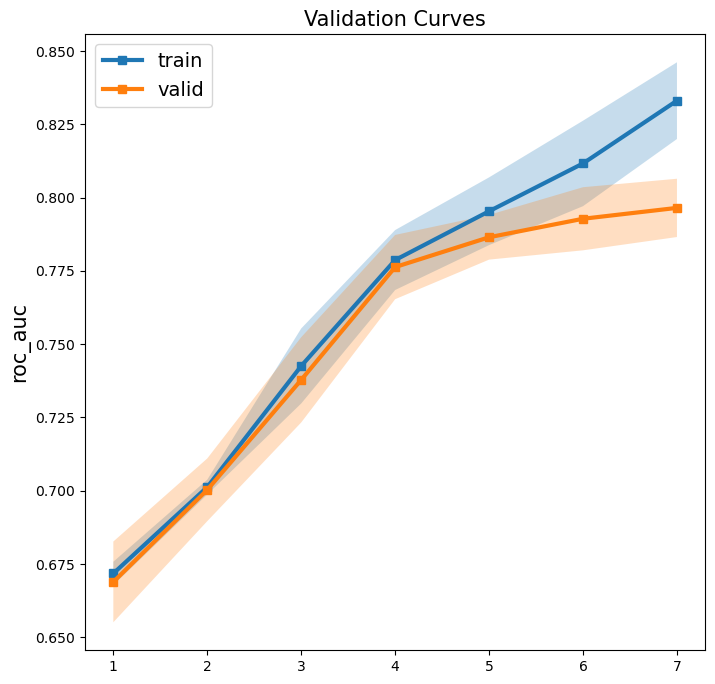

In [34]:
plot_validation_curves(train_scores, valid_scores)